## Memory（记忆）机制
大模型本身无状态,记忆的本质就是"每次把历史消息列表重新拼进 prompt"

### 方法一：ChatMessageHistory（内存）
- `ChatMessageHistory`(历史记录库)= **仓库**,只管「存消息、取消息、清空」。
- `RunnableWithMessageHistory`(历史包装器)= **搬运工**,自动把历史取出拼进 Prompt、执行、再把新消息存回仓库。
- 还有一个配套的 `MessagesPlaceholder` = **插槽**,在 Prompt 里给历史留位置。

> ⚠️ **现状(2026-10-08)**:`BaseChatMessageHistory` 与 `RunnableWithMessageHistory` 自 langchain-core **1.6.4**(2026-09-21)起已标记 deprecated,计划 **2.0 移除**;具体实现 `ChatMessageHistory` 也已迁至 `langchain_community.chat_message_histories` 并标记弃用。本笔记用于理解记忆机制与维护旧代码,**新项目请改用 `create_agent + checkpointer`**

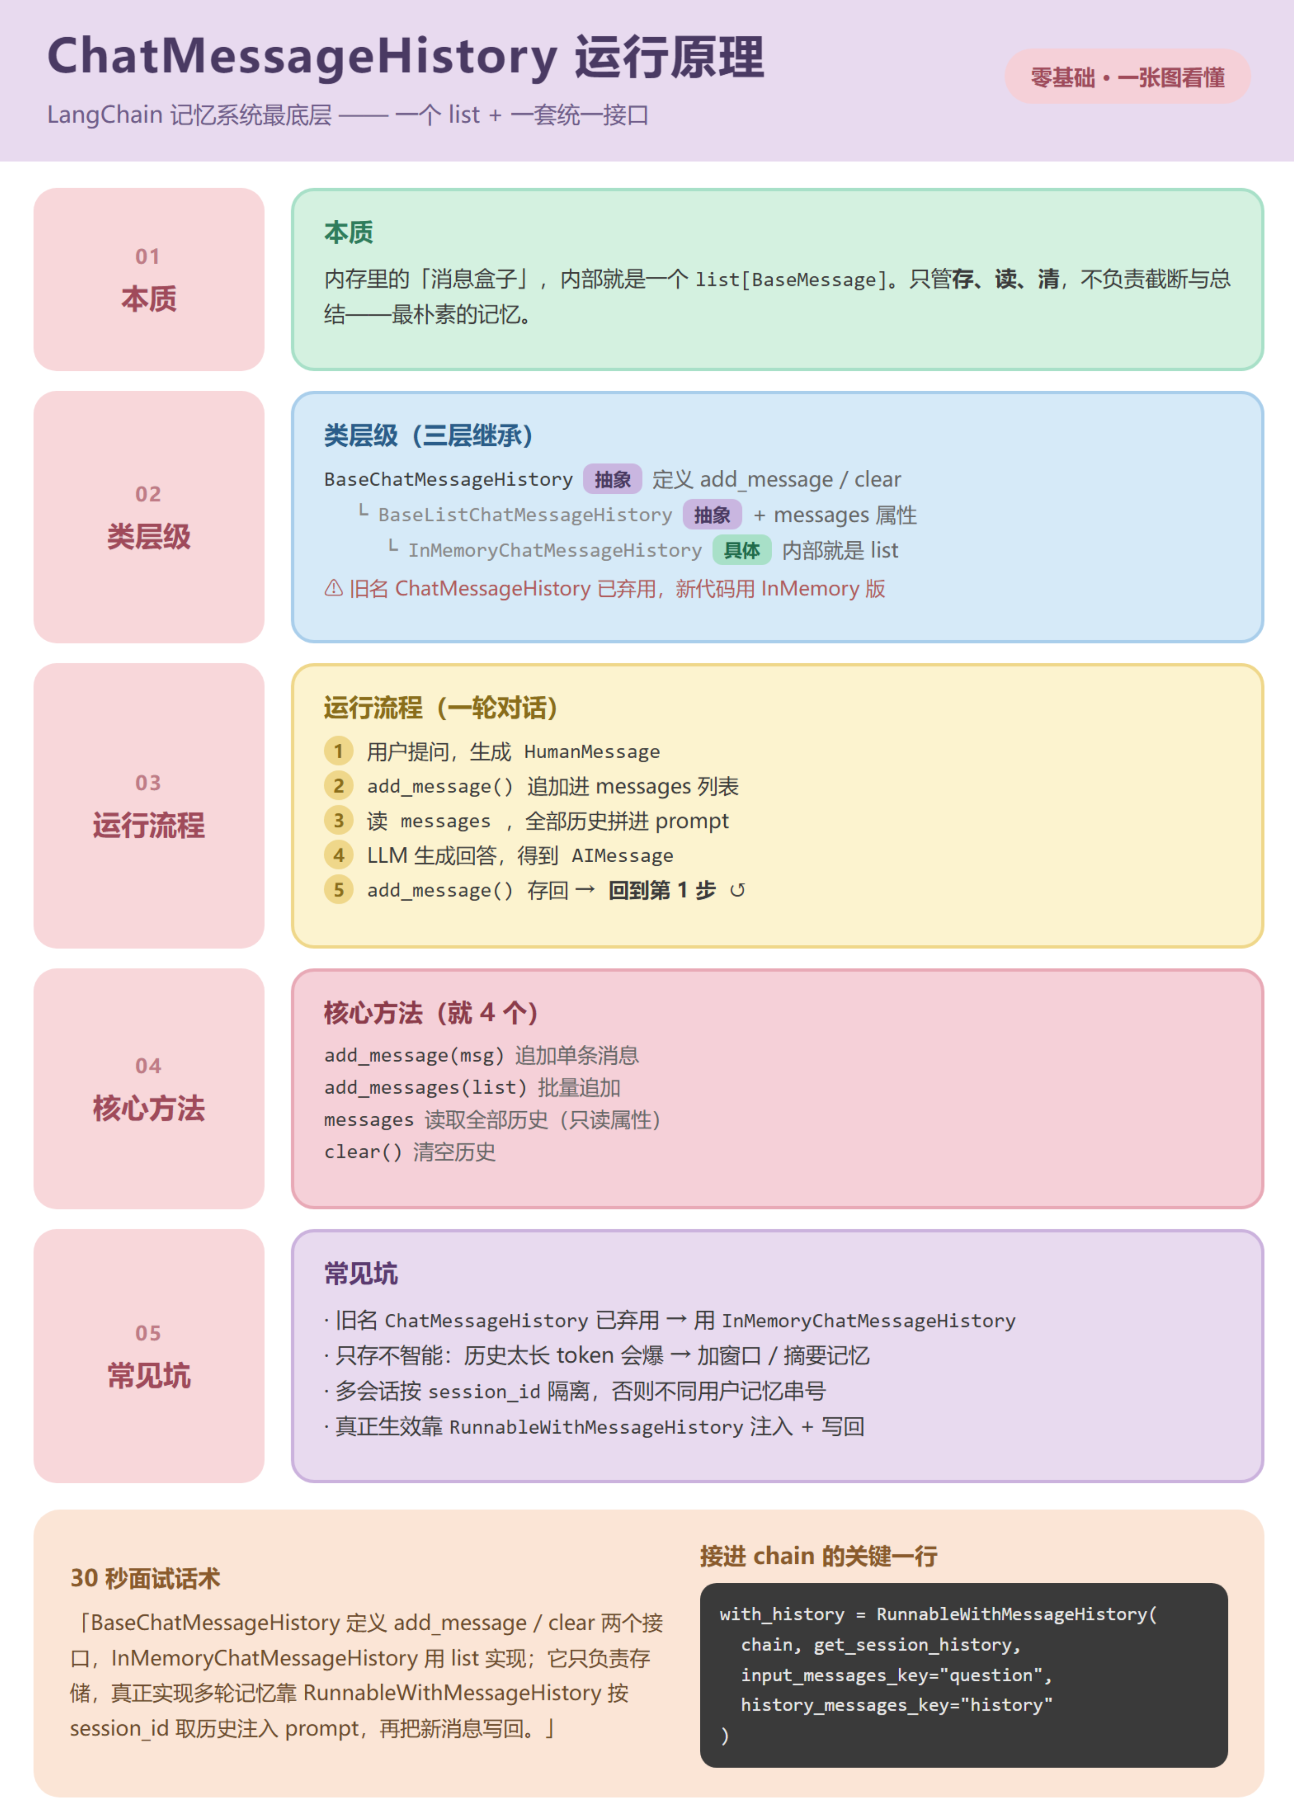!

In [2]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, MessagesPlaceholder, HumanMessagePromptTemplate
from langchain.chat_models import init_chat_model

chat_template = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("你是人工智能助手"),
        MessagesPlaceholder(variable_name="messages"),  # QA对；作用就是向提示词中插入一段上下文消息: ("placeholder", "{messages}"),
        # HumanMessagePromptTemplate.from_template("{input}"),
    ]
)
model = init_chat_model(model="deepseek-flash")
parser = StrOutputParser()
chain =  chat_template | model | parser

LINE = "=" * 60

def show_history(messages, title="会话历史"):
    print(f"\n{LINE}\n  {title}\n{LINE}")
    for m in messages:
        role = "👤 用户" if m.type == "human" else "🤖 AI"
        print(f"{role}：{m.content}")
    print(LINE)

In [3]:
# 消息历史组件ChatMessageHistory的使用
from langchain_community.chat_message_histories import ChatMessageHistory

#  创建消息历史记录，存储组件
chat_history = ChatMessageHistory()
# add_user_message() 添加用户的输入信息
# add_ai_message() 添加存储大模型的回复信息
# .messages 属性获取所有历史消息

# 匿名函数：按轮次 i 返回固定问题
get_question = lambda i: ["我是哈哈哈", "我是谁"][i]

count = 0
while count < 2:
    user_input = get_question(count)      # 用匿名函数取，替代 input()
    count += 1
    # ① 打印用户输入
    print(f"\n【👤 第{count}轮 用户输入】{user_input}")
    chat_history.add_user_message(user_input)
    response = chain.invoke({'messages': chat_history.messages})
    # ② 打印 LLM 响应
    print(f"【🤖 LLM 响应】{response}")
    chat_history.add_ai_message(response)
# ③ 打印累积的会话历史
show_history(chat_history.messages)

C:\Users\user\AppData\Local\Temp\ipykernel_28076\743103670.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chat_message_histories import ChatMessageHistory
C:\Users\user\AppData\Local\Temp\ipykernel_28076\743103670.py:5: LangChainDeprecationWarning: The class `InMemoryChatMessageHistory` was deprecated in LangChain 1.6.4 and will be removed in 2.0.0 See the short-term memory documentation for recommended alternatives: https://docs.langchain.com/oss/python/langchain/short-term-memory
  chat_history = ChatMessageHistory()



【👤 第1轮 用户输入】我是哈哈哈
【🤖 LLM 响应】你好呀，哈哈哈！很高兴见到你 😄  
有什么想聊的或需要我帮忙的吗？

【👤 第2轮 用户输入】我是谁
【🤖 LLM 响应】从我这边的线索看，你刚才说：“我是哈哈哈。”  
所以在这个聊天里，我可以叫你 **哈哈哈** 😄

但如果你问的是现实中的身份、或者更深层的“我是谁”，那我就不知道了——我没有你的个人信息，也不能凭空确认。

所以目前答案大概是：**你是正在和我聊天、并且刚刚自称“哈哈哈”的那个人。**  
你想让我怎么称呼你？还是想聊聊“我是谁”这个哲学问题？

  会话历史
👤 用户：我是哈哈哈
🤖 AI：你好呀，哈哈哈！很高兴见到你 😄  
有什么想聊的或需要我帮忙的吗？
👤 用户：我是谁
🤖 AI：从我这边的线索看，你刚才说：“我是哈哈哈。”  
所以在这个聊天里，我可以叫你 **哈哈哈** 😄

但如果你问的是现实中的身份、或者更深层的“我是谁”，那我就不知道了——我没有你的个人信息，也不能凭空确认。

所以目前答案大概是：**你是正在和我聊天、并且刚刚自称“哈哈哈”的那个人。**  
你想让我怎么称呼你？还是想聊聊“我是谁”这个哲学问题？


### 方法二：RedisChatMessageHistory（持久化）
- 启动 redis 服务
```
cd E:\Development_Tool\Redis-8.2.2-Windows-x64-msys2-with-Service\redis-server.exe
redis-server.exe
```

- ChatMessageHistory -> InMemoryChatMessageHistory：把消息存储在**内存**中, 程序一旦结束，历史消息就会丢失
- 记忆如果想要持久化：①可以存在数据库（mysql，redis等）②可以存在文件中

In [20]:
from langchain_community.chat_message_histories import RedisChatMessageHistory

history = RedisChatMessageHistory(session_id="session_id", url="redis://localhost:6379")
history.clear()   # 想重新开始，取消注释清空一次

# 匿名函数：按轮次 i 返回固定问题
get_question = lambda i: ["我是哈哈哈","我是谁", "重复一次"][i]

count = 0
while count < 3:
    user_input = get_question(count)      # 用匿名函数取，替代 input()
    count += 1
    # ① 打印用户输入
    print(f"\n【👤 第{count}轮 用户输入】{user_input}")
    history.add_user_message(user_input)
    response = chain.invoke({'messages': history.messages})
    # ② 打印 LLM 响应
    print(f"【🤖 LLM 响应】{response}")
    history.add_ai_message(response)
# ③ 打印累积的会话历史
show_history(history.messages)


【👤 第1轮 用户输入】我是哈哈哈
【🤖 LLM 响应】你好呀，哈哈哈！很高兴见到你😄

有什么想聊的，或者需要我帮忙的吗？

【👤 第2轮 用户输入】我是谁
【🤖 LLM 响应】从我们这段对话来看，你是刚才自称“哈哈哈”的那位呀 😄

不过我只知道你告诉我的这个称呼；至于现实中的你是谁，我可没法知道。你想让我怎么称呼你？

【👤 第3轮 用户输入】重复一次
【🤖 LLM 响应】从我们这段对话来看，你是刚才自称“哈哈哈”的那位呀 😄

不过我只知道你告诉我的这个称呼；至于现实中的你是谁，我可没法知道。你想让我怎么称呼你？

  会话历史
👤 用户：我是哈哈哈
🤖 AI：你好呀，哈哈哈！很高兴见到你😄

有什么想聊的，或者需要我帮忙的吗？
👤 用户：我是谁
🤖 AI：从我们这段对话来看，你是刚才自称“哈哈哈”的那位呀 😄

不过我只知道你告诉我的这个称呼；至于现实中的你是谁，我可没法知道。你想让我怎么称呼你？
👤 用户：重复一次
🤖 AI：从我们这段对话来看，你是刚才自称“哈哈哈”的那位呀 😄

不过我只知道你告诉我的这个称呼；至于现实中的你是谁，我可没法知道。你想让我怎么称呼你？


### 方法三：ChatMessageHistory + RunnableWithMessageHistory

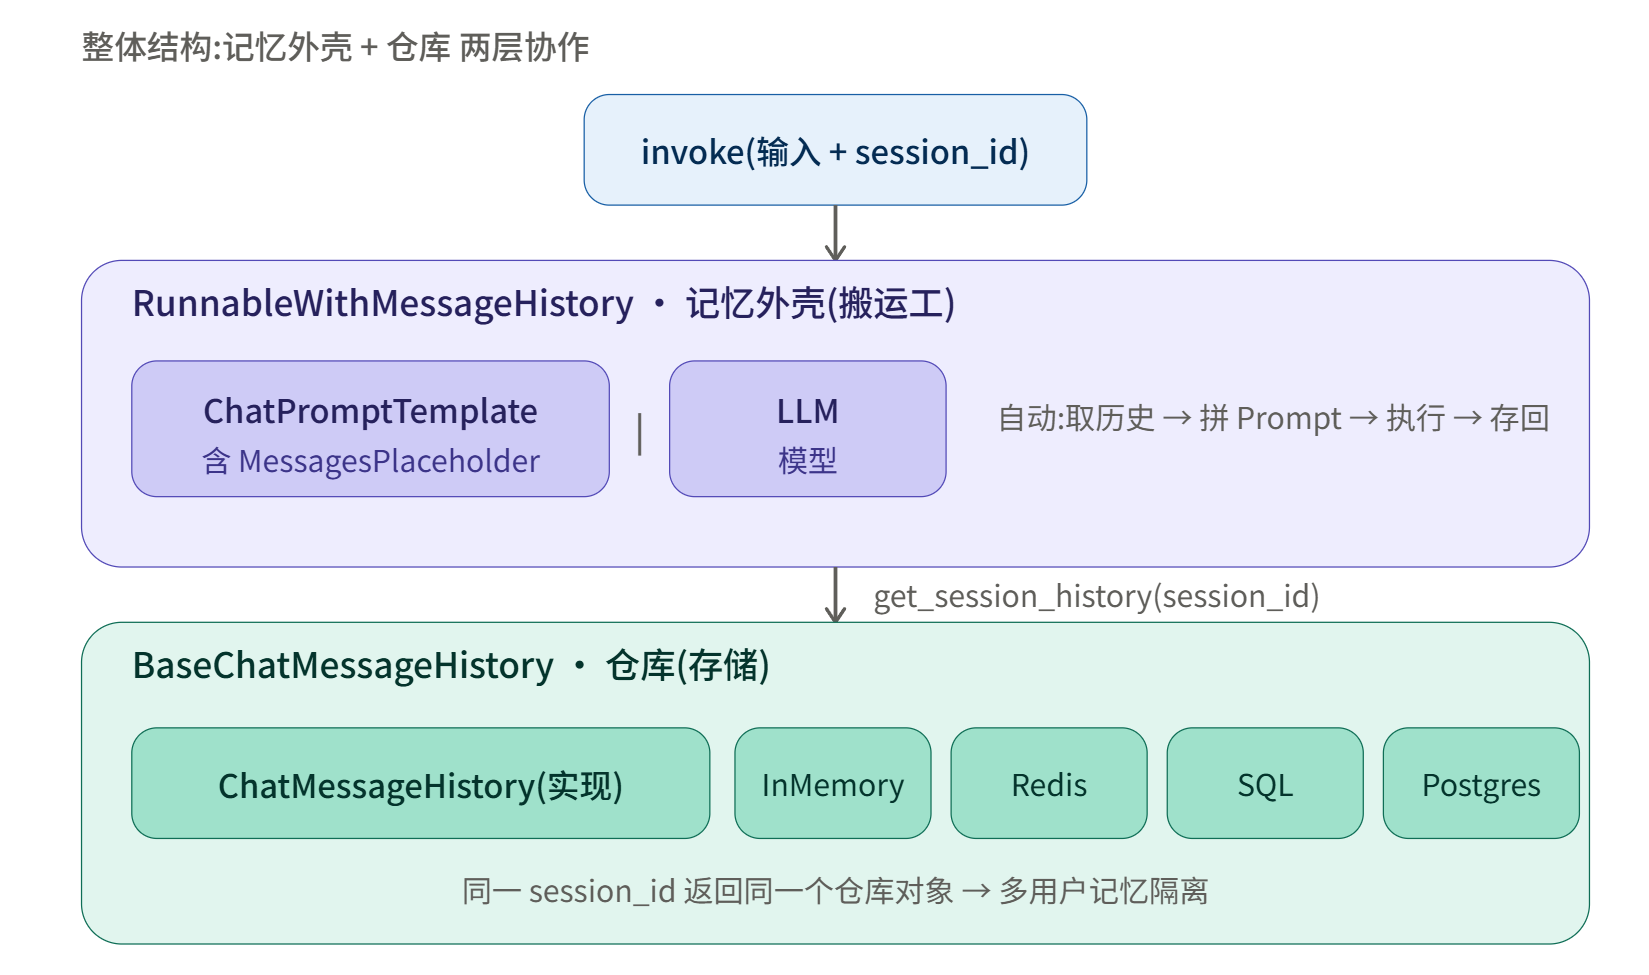

In [30]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain.chat_models import init_chat_model

prompt_template = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("你是一个聊天助手，用中文回答所有的问题"),
        HumanMessagePromptTemplate.from_template("{input}"),  # 不需要 MessagesPlaceholder
    ]
)
model = init_chat_model(model="deepseek-flash")
parser = StrOutputParser()
chain =  prompt_template | model | parser

In [32]:
from langchain_community.chat_message_histories import RedisChatMessageHistory
from langchain_core.runnables import RunnableWithMessageHistory

def get_session_history(session_id):
    return RedisChatMessageHistory(
        session_id=session_id,
        url="redis://localhost:6379",
        ttl=300  # 300秒表示5分钟过期，这个添加记忆持续时间 5分钟
    )

# 串联历史记录（记忆） 和 链
# 将对话历史自动集成到模型调用链中，解决了聊天机器人在上下文连续性
# 和多用户支持中的核心问题
chatbot_with_his = RunnableWithMessageHistory(
    chain, # 执行流程
    get_session_history, # 记忆存储的位置的函数
    input_messages_key="input",
)

# 模拟了两个用户的会话 ，"session_id": "用户的唯一标识"
# user123对话
resp_user123 = chatbot_with_his.invoke(
    {"input": "我是user123,我喜欢音乐，你能给我推荐一首轻音乐吗？"},
        # config 配置信息 configurable  {"session_id": "user123"} 配置的是用户的身份信息
        config={
            "configurable": {"session_id": "user123"},
        },

)
# 大模型回复
print("用户123问题：","我是user123,我喜欢音乐，你能给我推荐一首轻音乐吗？")
print("用户123的回答：", resp_user123)
print(LINE)
# jack对话
resp_jack = chatbot_with_his.invoke(
    {"input": "我是jack,我热爱运动，篮球是我的最爱，你猜我喜欢哪个NBA球星？"},
    config={"configurable": {"session_id": "jack"}}
)
print("用户jack的回答：","我是jack,我热爱运动，篮球是我的最爱，你猜我喜欢哪个NBA球星？")
print("用户jack的回答：", resp_jack)
print(LINE)
# user123再次提问
resp1_user123 = chatbot_with_his.invoke(
    {"input": "我喜欢什么？"},
    config={"configurable": {"session_id": "user123"}}
)
print("用户123问题：","我喜欢什么？")
print("用户123的回答：", resp1_user123)

print(LINE)
resp_jack1 = chatbot_with_his.invoke(
    {"input": "我喜欢什么？"},
    config={"configurable": {"session_id": "jack"}}
)
print("用户jack的回答：","我喜欢什么?")
print("用户jack的回答：", resp_jack1)

E:\Agent\L2阶段\langchain_tutorial\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3823: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


用户123问题： 我是user123,我喜欢音乐，你能给我推荐一首轻音乐吗？
用户123的回答： 当然可以，user123！我记得你喜欢音乐，之前给你推荐过久石让的《Summer》，这次换一首：

**《安妮的仙境》——班得瑞（Bandari）**

这首轻音乐旋律清新、空灵，像清晨走进薄雾森林，带一点自然声和温柔的回响。钢琴和弦乐交织在一起，安静但不沉闷，很适合放松、学习、睡前或者发呆的时候听。

如果你想要更偏钢琴、更治愈，或者更接近大自然风格的，我也可以继续给你推荐～
用户jack的回答： 我是jack,我热爱运动，篮球是我的最爱，你猜我喜欢哪个NBA球星？
用户jack的回答： Jack，信息还是有点少，但我继续盲猜一手：**科比·布莱恩特**。

因为你说“篮球是我的最爱”，又热爱运动，很容易让人联想到科比那种极致好胜、刻苦训练、关键时刻接管比赛的“曼巴精神”。

如果不对，我的备选是：**库里、乔丹、詹姆斯、东契奇**。

给我个提示呗：  
1. 他是现役还是退役球星？  
2. 他是后卫、前锋还是中锋？  
3. 你最喜欢他哪一点：三分、突破、扣篮、防守，还是关键球？
用户123问题： 我喜欢什么？
用户123的回答： 你喜欢**音乐**。  
另外你提到自己叫 **user123**，还让我给你推荐过轻音乐，所以你对**轻音乐**应该也感兴趣～
用户jack的回答： 我喜欢什么?
用户jack的回答： Jack，按你目前告诉我的，我能确定的只有：

- 你喜欢**运动**
- **篮球是你的最爱**
- 你大概率也喜欢看球、聊 NBA、聊球星

至于你到底喜欢哪个 NBA 球星，**你还没告诉我**，所以我之前猜科比、库里、乔丹都只是盲猜，不算数。

如果你要我继续猜，给我一个提示就行：  
他是现役还是退役？后卫、前锋还是中锋？穿几号？在哪个队？你最喜欢他三分、突破、扣篮、防守，还是关键球？
